In [4]:
# 1. Install DuckDB
!pip install duckdb --quiet

import duckdb

# 2. Read exact column names directly from the raw CSV
url = "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv"
duckdb.sql(f"CREATE OR REPLACE TABLE bank_customers AS SELECT * FROM read_csv_auto('{url}', header=True)")

# 3. Print exact column names loaded into DuckDB
print("✅ Table loaded successfully! Here are your exact database columns:")
cols = duckdb.sql("DESCRIBE bank_customers").df()
print(list(cols['column_name']))

✅ Table loaded successfully! Here are your exact database columns:
['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'Num Of Products', 'Has Credit Card', 'Is Active Member', 'Estimated Salary', 'Churn']


In [5]:
#Regional Risk & Lost Capital Analysis

duckdb.sql("""
SELECT
    Geography,
    COUNT(CustomerId) AS Total_Customers,
    SUM(Churn) AS Churned_Customers,
    ROUND(SUM(Churn) * 100.0 / COUNT(CustomerId), 2) AS Churn_Rate_Pct,
    ROUND(AVG(CreditScore), 0) AS Avg_Credit_Score,
    ROUND(SUM(CASE WHEN Churn = 1 THEN Balance ELSE 0 END), 2) AS Total_Lost_Capital_USD
FROM bank_customers
GROUP BY Geography
ORDER BY Churn_Rate_Pct DESC;
""").show()

┌───────────┬─────────────────┬───────────────────┬────────────────┬──────────────────┬────────────────────────┐
│ Geography │ Total_Customers │ Churned_Customers │ Churn_Rate_Pct │ Avg_Credit_Score │ Total_Lost_Capital_USD │
│  varchar  │      int64      │      int128       │     double     │      double      │         double         │
├───────────┼─────────────────┼───────────────────┼────────────────┼──────────────────┼────────────────────────┤
│ Germany   │            2509 │               814 │          32.44 │            651.0 │            97973915.53 │
│ Spain     │            2477 │               413 │          16.67 │            651.0 │            29948014.56 │
│ France    │            5014 │               810 │          16.15 │            650.0 │            57666164.54 │
└───────────┴─────────────────┴───────────────────┴────────────────┴──────────────────┴────────────────────────┘



In [6]:
#Churned VIPs per Country (Window Function)

duckdb.sql("""
WITH RankedCustomers AS (
    SELECT
        Geography,
        CustomerId,
        Surname,
        Balance,
        CreditScore,
        DENSE_RANK() OVER (PARTITION BY Geography ORDER BY Balance DESC) AS Rank_In_Country
    FROM bank_customers
    WHERE Churn = 1
)
SELECT *
FROM RankedCustomers
WHERE Rank_In_Country <= 3;
""").show()

┌───────────┬────────────┬────────────┬───────────┬─────────────┬─────────────────┐
│ Geography │ CustomerId │  Surname   │  Balance  │ CreditScore │ Rank_In_Country │
│  varchar  │   int64    │  varchar   │  double   │    int64    │      int64      │
├───────────┼────────────┼────────────┼───────────┼─────────────┼─────────────────┤
│ France    │   15715622 │ To Rot     │ 238387.56 │         583 │               1 │
│ France    │   15671256 │ Macartney  │ 211774.31 │         850 │               2 │
│ France    │   15736420 │ Macdonald  │ 210433.08 │         596 │               3 │
│ Spain     │   15757408 │ Lo         │ 250898.09 │         655 │               1 │
│ Spain     │   15714241 │ Haddon     │ 222267.63 │         749 │               2 │
│ Spain     │   15586674 │ Shaw       │ 216109.88 │         663 │               3 │
│ Germany   │   15801559 │ Chiang     │ 181461.48 │         693 │               1 │
│ Germany   │   15743817 │ Hargreaves │ 174126.75 │         621 │           

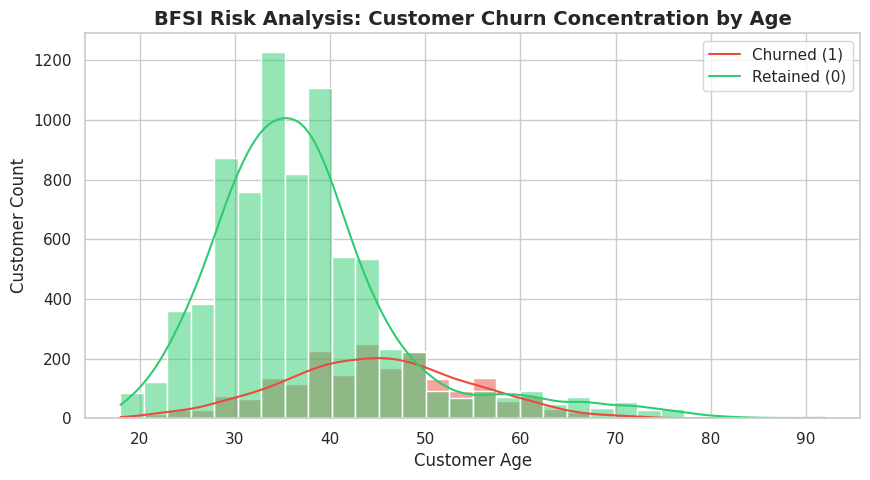

/tmp/ipykernel_2614/2890885270.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Num Of Products", y="Churn", errorbar=None, palette="Blues_d")


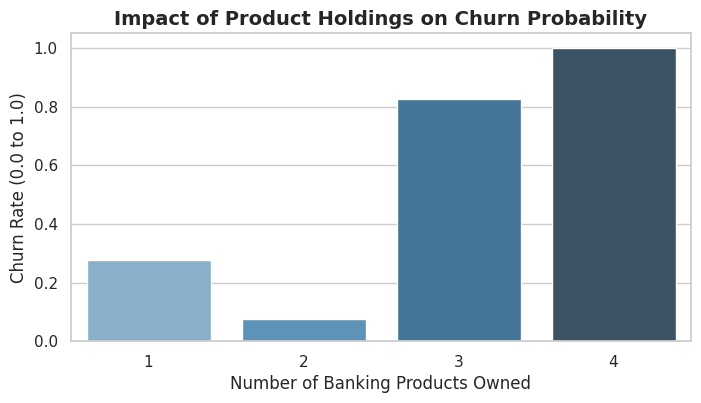

In [7]:
#Python EDA & Visualizations

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset into a Pandas DataFrame
df = duckdb.sql("SELECT * FROM bank_customers").df()

# Set visual style
sns.set_theme(style="whitegrid")

# 2. Visual 1: Churn Distribution by Customer Age
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="Age", hue="Churn", kde=True, bins=30, palette={0: "#2ecc71", 1: "#e74c3c"})
plt.title("BFSI Risk Analysis: Customer Churn Concentration by Age", fontsize=14, fontweight="bold")
plt.xlabel("Customer Age")
plt.ylabel("Customer Count")
plt.legend(["Churned (1)", "Retained (0)"])
plt.show()

# 3. Visual 2: Churn Probability by Number of Products Held
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x="Num Of Products", y="Churn", errorbar=None, palette="Blues_d")
plt.title("Impact of Product Holdings on Churn Probability", fontsize=14, fontweight="bold")
plt.ylabel("Churn Rate (0.0 to 1.0)")
plt.xlabel("Number of Banking Products Owned")
plt.show()